*italicized text*# **Thyroid Disease Detection**

In [ ]:
# Install required libraries (Kaggle usually has these, but just in case)
!pip install lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score

# Plot Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [ ]:
# Read/Import Dataset
df = pd.read_csv("/content/drive/MyDrive/heart disease/cardio_train.csv", sep=";")

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [ ]:
print(df.info())

print("\n")

print(df.describe())

print("\n")

print(df.isnull().sum())

print("\nDuplicate Records :", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB
None


                 id           age        gender        height        weight  \
count  70000.000000  70000.000000  70000.000000  70000.000000  70000.000000   
mean   49972.419900  19468.865814      1.3495

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("="*70)
print("INITIAL DATASET INFORMATION")
print("="*70)

print("\nShape :", df.shape)

print("\nInformation")
print(df.info())

print("\nStatistical Summary")
print(df.describe(include="all"))

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

print("="*70)


initial_rows = len(df)

df.drop_duplicates(inplace=True)

print(f"Removed {initial_rows-len(df)} duplicate rows")


df["age_years"] = (df["age"]/365).astype(int)

df["height_m"] = df["height"]/100

df["BMI"] = df["weight"]/(df["height_m"]**2)

df.drop(columns=["height_m"], inplace=True)

# Blood Pressure Category

def bp_category(sys, dia):

    if sys < 120 and dia < 80:
        return "Normal"

    elif 120 <= sys < 130 and dia < 80:
        return "Elevated"

    elif (130 <= sys < 140) or (80 <= dia < 90):
        return "Stage-1"

    elif sys >= 140 or dia >= 90:
        return "Stage-2"

    return "Unknown"

df["bp_category"] = df.apply(
    lambda x: bp_category(x["ap_hi"], x["ap_lo"]),
    axis=1
)


print("\nRemoving Impossible Values...")

df = df[df["height"]>=120]
df = df[df["height"]<=230]

df = df[df["weight"]>=35]
df = df[df["weight"]<=220]

df = df[df["ap_hi"]>0]
df = df[df["ap_lo"]>0]

df = df[df["ap_hi"]>df["ap_lo"]]

df = df[df["BMI"]<60]

print("Shape After Cleaning :", df.shape)


numerical_cols = [
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "BMI"
]

for col in numerical_cols:

    q1 = df[col].quantile(.25)
    q3 = df[col].quantile(.75)

    iqr = q3-q1

    lower = q1-1.5*iqr
    upper = q3+1.5*iqr

    df = df[
        (df[col]>=lower)&
        (df[col]<=upper)
    ]

print("Shape After Outlier Removal :", df.shape)

print(df.head())

print(df.describe())

INITIAL DATASET INFORMATION

Shape : (70000, 13)

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB
None

Statistical Summary
                 id           age        gender        height        weight  \
count  70000.000000  70000.000000  70000.00

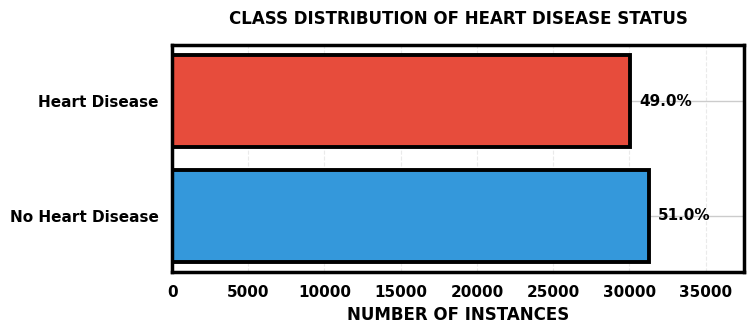

✅ Heart disease distribution plot saved successfully.


In [ ]:
import matplotlib.pyplot as plt

# Map target values
label_map = {
    0: "No Heart Disease",
    1: "Heart Disease"
}

df["Cardio_Status"] = df["cardio"].map(label_map)
counts = df["Cardio_Status"].value_counts()

fig, ax = plt.subplots(figsize=(7.7, 3.5), facecolor="white")
ax.set_facecolor("white")

# Colors
colors_for_bars = []

for label in counts.index:
    if label == "No Heart Disease":
        colors_for_bars.append("#3498db")   # Blue
    elif label == "Heart Disease":
        colors_for_bars.append("#e74c3c")   # Red
    else:
        colors_for_bars.append("#999999")

bars = ax.barh(
    counts.index,
    counts.values,
    color=colors_for_bars,
    edgecolor="black",
    linewidth=2.8
)

ax.set_title(
    "CLASS DISTRIBUTION OF HEART DISEASE STATUS",
    fontsize=12,
    fontweight="bold",
    pad=15,
    color="black"
)

ax.set_xlabel(
    "NUMBER OF INSTANCES",
    fontsize=12,
    fontweight="bold",
    color="black"
)

ax.tick_params(axis='x', colors='black', labelsize=11, width=2, length=6)
ax.tick_params(axis='y', colors='black', labelsize=11, width=2, length=6)

# Bold tick labels
for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# Show only percentage
total = counts.sum()

for bar in bars:
    width = bar.get_width()

    ax.text(
        width + total * 0.01,
        bar.get_y() + bar.get_height()/2,
        f"{width/total*100:.1f}%",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold",
        color="black"
    )

# Border
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(2.5)

# Grid
ax.grid(axis='x', linestyle='--', linewidth=0.8, alpha=0.4)

ax.set_xlim(0, max(counts.values) * 1.20)

plt.tight_layout()

plt.savefig(
    "heart_disease_distribution.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("✅ Heart disease distribution plot saved successfully.")

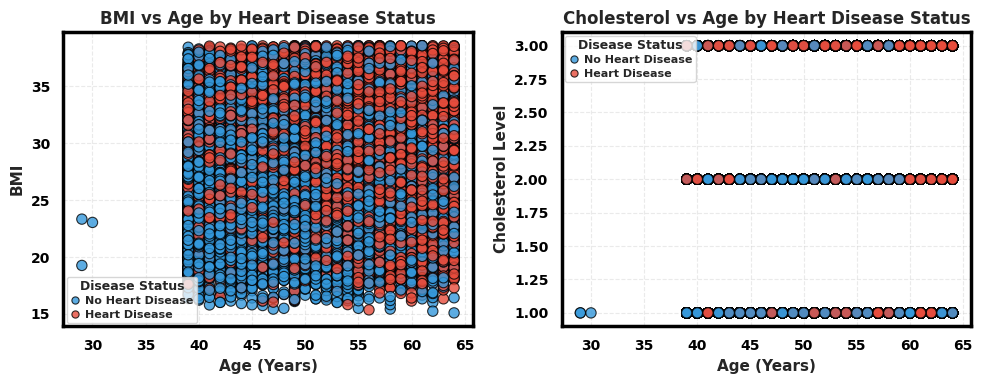

✅ Figure saved successfully.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- Create Labels --------------------
plot_df = df.copy()

plot_df["Cardio_Status"] = plot_df["cardio"].map({
    0: "No Heart Disease",
    1: "Heart Disease"
})

# Color palette
palette = {
    "No Heart Disease": "#3498db",
    "Heart Disease": "#e74c3c"
}

# -------------------- Create Figure --------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor="white")

# -------------------- Plot 1 --------------------
sns.scatterplot(
    data=plot_df,
    x="age_years",
    y="BMI",
    hue="Cardio_Status",
    palette=palette,
    alpha=0.8,
    s=55,
    edgecolor="black",
    linewidth=0.8,
    ax=axes[0]
)

axes[0].set_title(
    "BMI vs Age by Heart Disease Status",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Age (Years)",
    fontsize=11,
    fontweight="bold"
)

axes[0].set_ylabel(
    "BMI",
    fontsize=11,
    fontweight="bold"
)

# -------------------- Plot 2 --------------------
sns.scatterplot(
    data=plot_df,
    x="age_years",
    y="cholesterol",
    hue="Cardio_Status",
    palette=palette,
    alpha=0.8,
    s=55,
    edgecolor="black",
    linewidth=0.8,
    ax=axes[1]
)

axes[1].set_title(
    "Cholesterol vs Age by Heart Disease Status",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_xlabel(
    "Age (Years)",
    fontsize=11,
    fontweight="bold"
)

axes[1].set_ylabel(
    "Cholesterol Level",
    fontsize=11,
    fontweight="bold"
)

# -------------------- Common Formatting --------------------
for ax in axes:

    ax.set_facecolor("white")

    ax.tick_params(
        axis='both',
        labelsize=10,
        width=2,
        length=6,
        colors="black"
    )

    # Bold tick labels
    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")

    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

    # Thick border
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
        spine.set_color("black")

    # Grid
    ax.grid(
        linestyle="--",
        linewidth=0.8,
        alpha=0.4
    )

    # Compact legend
    legend = ax.legend(
        title="Disease Status",
        fontsize=8,
        title_fontsize=9,
        markerscale=0.7,
        frameon=True,
        borderpad=0.3,
        labelspacing=0.3,
        handlelength=1.0,
        handletextpad=0.4,
        borderaxespad=0.3,
        loc="best"
    )

    legend.get_title().set_fontweight("bold")

    for text in legend.get_texts():
        text.set_fontweight("bold")

# -------------------- Save Figure --------------------
plt.tight_layout()

plt.savefig(
    "BMI_Cholesterol_vs_Age.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("✅ Figure saved successfully.")

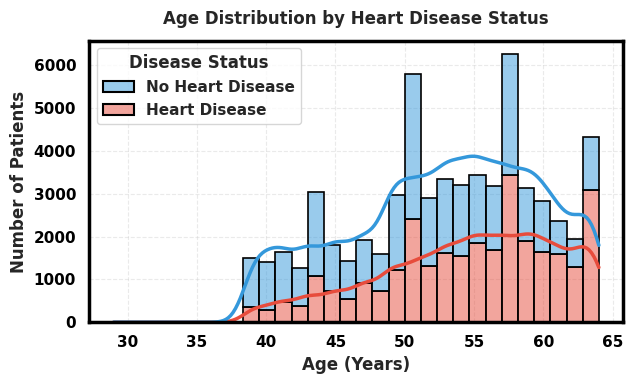

✅ Age distribution plot saved successfully.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create readable labels
plot_df = df.copy()

# Ensure age_years exists
if "age_years" not in plot_df.columns:
    plot_df["age_years"] = (plot_df["age"] / 365).astype(int)

plot_df["Cardio_Status"] = plot_df["cardio"].map({
    0: "No Heart Disease",
    1: "Heart Disease"
})

plt.figure(figsize=(6.5, 4), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

# Histogram
sns.histplot(
    data=plot_df,
    x="age_years",
    hue="Cardio_Status",
    palette=["#3498db", "#e74c3c"],
    bins=30,
    multiple="stack",
    kde=True,
    edgecolor="black",
    linewidth=1.2,
    line_kws={"linewidth": 2.5}
)

# Title
ax.set_title(
    "Age Distribution by Heart Disease Status",
    fontsize=12,
    fontweight="bold",
    pad=12
)

# Labels
ax.set_xlabel(
    "Age (Years)",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Patients",
    fontsize=12,
    fontweight="bold"
)

# Tick formatting
ax.tick_params(
    axis='both',
    labelsize=11,
    width=2,
    length=6,
    colors="black"
)

for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")

for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")

# Black border
for spine in ax.spines.values():
    spine.set_linewidth(2.5)
    spine.set_color("black")

# Grid
ax.grid(
    linestyle="--",
    linewidth=0.8,
    alpha=0.4
)

# Legend formatting
legend = ax.get_legend()

if legend:
    legend.set_title("Disease Status")
    legend.get_title().set_fontweight("bold")

    for text in legend.get_texts():
        text.set_fontweight("bold")

    # Bold legend color boxes
    for handle in legend.legend_handles:
        try:
            handle.set_edgecolor("black")
            handle.set_linewidth(1.5)
        except:
            pass

plt.tight_layout()

plt.savefig(
    "Age_Distribution_Heart_Disease.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("✅ Age distribution plot saved successfully.")

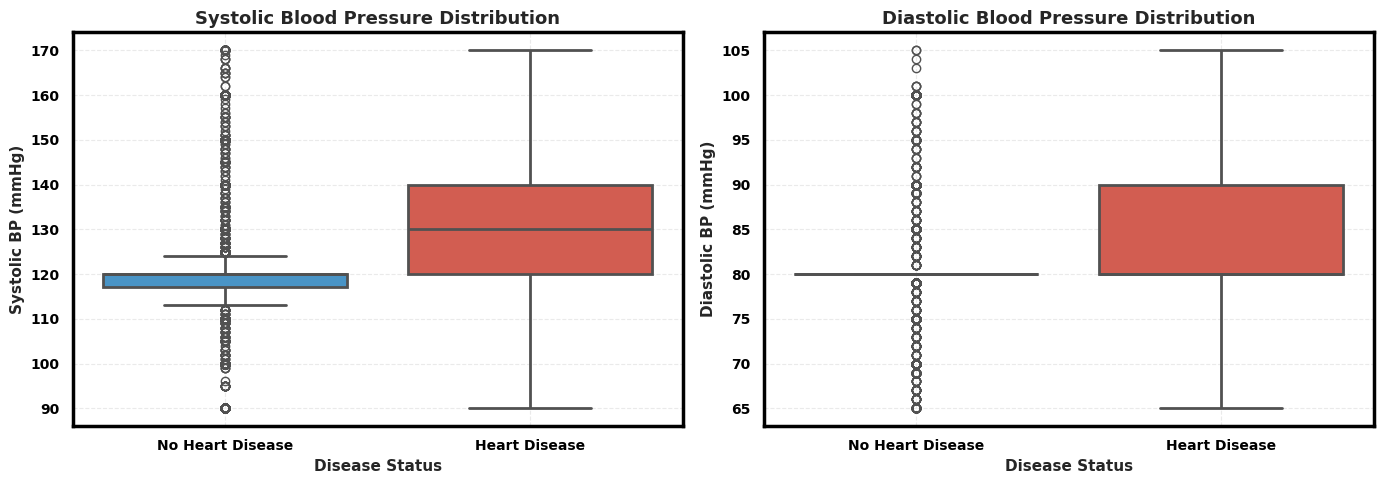

✅ Blood pressure distribution plot saved successfully.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Copy dataset
plot_df = df.copy()

# Create disease labels
plot_df["Cardio_Status"] = plot_df["cardio"].map({
    0: "No Heart Disease",
    1: "Heart Disease"
})

# Remove unrealistic blood pressure values
plot_df = plot_df[
    (plot_df["ap_hi"].between(80, 220)) &
    (plot_df["ap_lo"].between(40, 140))
]

# Color palette
palette = {
    "No Heart Disease": "#3498db",
    "Heart Disease": "#e74c3c"
}

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="white")

# -------------------- Systolic BP --------------------
sns.boxplot(
    data=plot_df,
    x="Cardio_Status",
    y="ap_hi",
    hue="Cardio_Status",
    palette=palette,
    linewidth=2,
    legend=False,
    ax=axes[0]
)

axes[0].set_title(
    "Systolic Blood Pressure Distribution",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel("Disease Status", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Systolic BP (mmHg)", fontsize=11, fontweight="bold")

# -------------------- Diastolic BP --------------------
sns.boxplot(
    data=plot_df,
    x="Cardio_Status",
    y="ap_lo",
    hue="Cardio_Status",
    palette=palette,
    linewidth=2,
    legend=False,
    ax=axes[1]
)

axes[1].set_title(
    "Diastolic Blood Pressure Distribution",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_xlabel("Disease Status", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Diastolic BP (mmHg)", fontsize=11, fontweight="bold")

# -------------------- Common Formatting --------------------
for ax in axes:

    ax.set_facecolor("white")

    ax.tick_params(
        axis='both',
        labelsize=10,
        width=2,
        length=6,
        colors="black"
    )

    # Bold tick labels
    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")

    for tick in ax.get_yticklabels():
        tick.set_fontweight("bold")

    # Thick black border
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)
        spine.set_color("black")

    # Grid
    ax.grid(
        linestyle="--",
        linewidth=0.8,
        alpha=0.4
    )

plt.tight_layout()

plt.savefig(
    "Blood_Pressure_Distribution.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("✅ Blood pressure distribution plot saved successfully.")

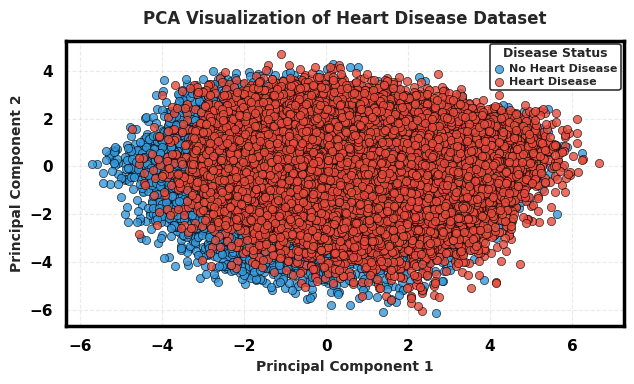

✅ PCA visualization saved successfully.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ---------------- Feature Selection ----------------
X = df.drop(columns=["id", "cardio", "bp_category", "Cardio_Status"])
y = df["cardio"]

# ---------------- Standardization ----------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------- PCA ----------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# ---------------- Plot ----------------
fig, ax = plt.subplots(figsize=(6.5, 4), facecolor="white")
ax.set_facecolor("white")

colors = {
    0: "#3498db",
    1: "#e74c3c"
}

labels = {
    0: "No Heart Disease",
    1: "Heart Disease"
}

for c in [0, 1]:
    ax.scatter(
        X_pca[y == c, 0],
        X_pca[y == c, 1],
        color=colors[c],
        label=labels[c],
        s=35,
        alpha=0.8,
        edgecolors="black",
        linewidths=0.5
    )

# ---------------- Titles ----------------
ax.set_title(
    "PCA Visualization of Heart Disease Dataset",
    fontsize=12,
    fontweight="bold",
    pad=12
)

ax.set_xlabel(
    "Principal Component 1",
    fontsize=10,
    fontweight="bold"
)

ax.set_ylabel(
    "Principal Component 2",
    fontsize=10,
    fontweight="bold"
)

# ---------------- Tick Formatting ----------------
ax.tick_params(
    axis='both',
    labelsize=11,
    width=2,
    length=6,
    colors="black"
)

for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")

for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")

# ---------------- Border ----------------
for spine in ax.spines.values():
    spine.set_linewidth(2.5)
    spine.set_color("black")

# ---------------- Grid ----------------
ax.grid(
    linestyle="--",
    linewidth=0.8,
    alpha=0.4
)

# ---------------- Compact Legend ----------------
legend = ax.legend(
    title="Disease Status",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    borderpad=0.3,
    labelspacing=0.3,
    handlelength=1.0,
    handletextpad=0.4,
    borderaxespad=0.3,
    loc="best"
)

legend.get_title().set_fontweight("bold")

for text in legend.get_texts():
    text.set_fontweight("bold")

legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(1.2)

plt.tight_layout()

plt.savefig(
    "PCA_Visualization.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("✅ PCA visualization saved successfully.")

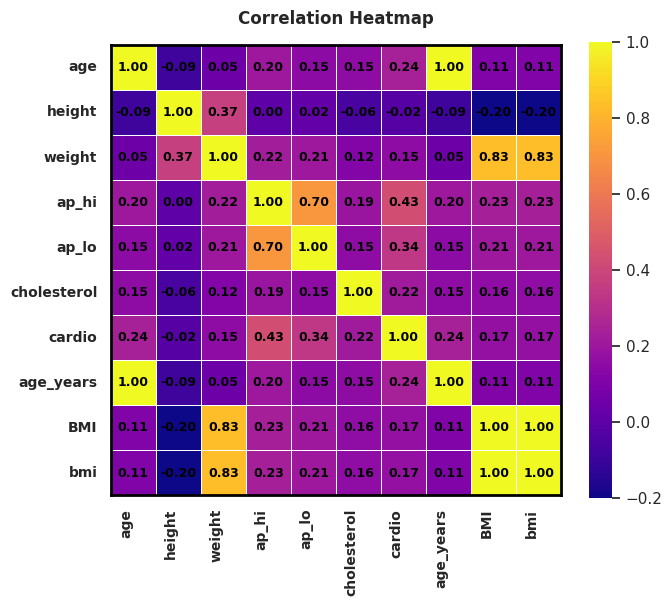

✅ Correlation heatmap saved successfully.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remove unwanted features for correlation analysis
corr_df = df.drop(columns=[
    "gender",
    "smoke",
    "alco",
    "active",
    "gluc",
    "id"
])

plt.figure(figsize=(7, 6), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

sns.heatmap(
    corr_df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="plasma",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar=True,
    annot_kws={
        "size": 9,
        "weight": "bold",
        "color": "black"
    }
)

ax.set_title(
    "Correlation Heatmap",
    fontsize=12,
    fontweight="bold",
    pad=15
)

plt.xticks(
    rotation=90,
    ha="right",
    fontsize=10,
    fontweight="bold"
)

plt.yticks(
    rotation=0,
    fontsize=10,
    fontweight="bold"
)

# Black border
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2)
    spine.set_color("black")

plt.tight_layout()

plt.savefig(
    "Correlation_Heatmap.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("✅ Correlation heatmap saved successfully.")

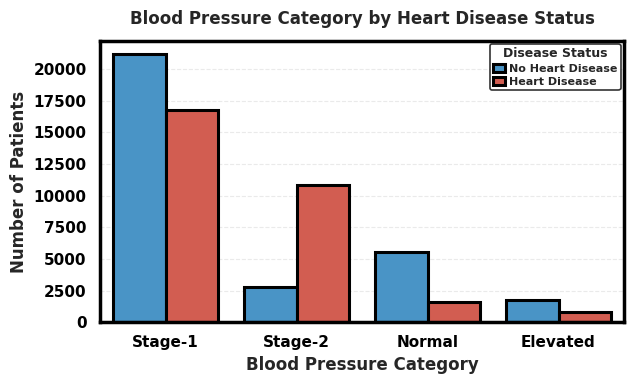

✅ Blood Pressure Category plot saved successfully.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Label mapping
plot_df = df.copy()
plot_df["Cardio_Status"] = plot_df["cardio"].map({
    0: "No Heart Disease",
    1: "Heart Disease"
})

plt.figure(figsize=(6.5, 4), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

sns.countplot(
    data=plot_df,
    x="bp_category",
    hue="Cardio_Status",
    palette={
        "No Heart Disease": "#3498db",
        "Heart Disease": "#e74c3c"
    },
    edgecolor="black",
    linewidth=2.2      # <-- Bold bar border
)

ax.set_title(
    "Blood Pressure Category by Heart Disease Status",
    fontsize=12,
    fontweight="bold",
    pad=12
)

ax.set_xlabel(
    "Blood Pressure Category",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of Patients",
    fontsize=12,
    fontweight="bold"
)

# Tick formatting
ax.tick_params(
    axis='both',
    labelsize=11,
    width=2,
    length=6,
    colors="black"
)

for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")
    tick.set_rotation(0)

for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")

# Grid
ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.8,
    alpha=0.4
)

# Thick black border
for spine in ax.spines.values():
    spine.set_linewidth(2.5)
    spine.set_color("black")

# ---------- Compact Legend ----------
legend = ax.legend(
    title="Disease Status",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    borderpad=0.3,
    labelspacing=0.3,
    handlelength=1.0,
    handletextpad=0.4,
    borderaxespad=0.3,
    loc="best"
)

legend.get_title().set_fontweight("bold")

for text in legend.get_texts():
    text.set_fontweight("bold")

legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(1.2)

plt.tight_layout()

plt.savefig(
    "Blood_Pressure_Category.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("✅ Blood Pressure Category plot saved successfully.")

In [ ]:
!pip install xgboost -q


In [ ]:
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [ ]:
X = df.drop(columns=["id", "cardio", "bp_category", "Cardio_Status"])
y = df["cardio"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)


Train Shape : (49063, 14)
Test Shape  : (12266, 14)


In [ ]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "Gaussian Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
}

results = []
trained_models = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

    print(f"\n{'='*60}")
    print(f"{name}")
    print(f"{'='*60}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")

    return model


In [ ]:

for name, model in models.items():
    if name in ["KNN", "Gaussian Naive Bayes"]:
        trained_models[name] = evaluate_model(
            name, model, X_train_scaled, X_test_scaled, y_train, y_test
        )
    else:
        trained_models[name] = evaluate_model(
            name, model, X_train, X_test, y_train, y_test
        )



KNN
Accuracy  : 0.7120
Precision : 0.7210
Recall    : 0.6727
F1-Score  : 0.6960

CatBoost
Accuracy  : 0.7296
Precision : 0.7455
Recall    : 0.6806
F1-Score  : 0.7116

AdaBoost
Accuracy  : 0.7200
Precision : 0.7543
Recall    : 0.6357
F1-Score  : 0.6900

Gaussian Naive Bayes
Accuracy  : 0.7050
Precision : 0.7299
Recall    : 0.6319
F1-Score  : 0.6774

Gradient Boosting
Accuracy  : 0.7274
Precision : 0.7411
Recall    : 0.6821
F1-Score  : 0.7104

Random Forest
Accuracy  : 0.7028
Precision : 0.7021
Recall    : 0.6836
F1-Score  : 0.6927

LightGBM
Accuracy  : 0.7275
Precision : 0.7426
Recall    : 0.6798
F1-Score  : 0.7098


In [ ]:
lgbm_clf = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)

xgb_clf = XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    use_label_encoder=False
)

rf_clf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_estimators=200
)

lxrf_ensemble = VotingClassifier(
    estimators=[
        ("lightgbm", lgbm_clf),
        ("xgboost", xgb_clf),
        ("random_forest", rf_clf)
    ],
    voting="soft"
)

trained_models["LXRF-Ensemble (Proposed)"] = evaluate_model(
    "LXRF-Ensemble (Proposed)",
    lxrf_ensemble,
    X_train, X_test, y_train, y_test
)



LXRF-Ensemble (Proposed)
Accuracy  : 0.7244
Precision : 0.7384
Recall    : 0.6778
F1-Score  : 0.7068


In [ ]:
lgbm_hybrid = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)

catboost_hybrid = CatBoostClassifier(verbose=0, random_state=RANDOM_STATE)

lc_hybrid = VotingClassifier(
    estimators=[
        ("lightgbm", lgbm_hybrid),
        ("catboost", catboost_hybrid)
    ],
    voting="soft"
)

trained_models["LC-Hybrid (LightGBM+CatBoost)"] = evaluate_model(
    "LC-Hybrid (LightGBM+CatBoost)",
    lc_hybrid,
    X_train, X_test, y_train, y_test
)


LC-Hybrid (LightGBM+CatBoost)
Accuracy  : 0.7279
Precision : 0.7433
Recall    : 0.6795
F1-Score  : 0.7099


### Results Comparison


In [ ]:
results_df = pd.DataFrame(results).sort_values(
    by="F1-Score", ascending=False
).reset_index(drop=True)

results_df


,Model,Accuracy,Precision,Recall,F1-Score
0,CatBoost,0.729578,0.745491,0.680639,0.711590
1,Gradient Boosting,0.727376,0.741055,0.682136,0.710376
2,LC-Hybrid (LightGBM+CatBoost),0.727866,0.743268,0.679474,0.709941
3,LightGBM,0.727540,0.742551,0.679807,0.709795
4,LXRF-Ensemble (Proposed),0.724360,0.738358,0.677811,0.706790
5,KNN,0.711968,0.720984,0.672655,0.695981
6,Random Forest,0.702756,0.702084,0.683633,0.692736
7,AdaBoost,0.719958,0.754292,0.635729,0.689954
8,Gaussian Naive Bayes,0.704957,0.729875,0.631903,0.677365


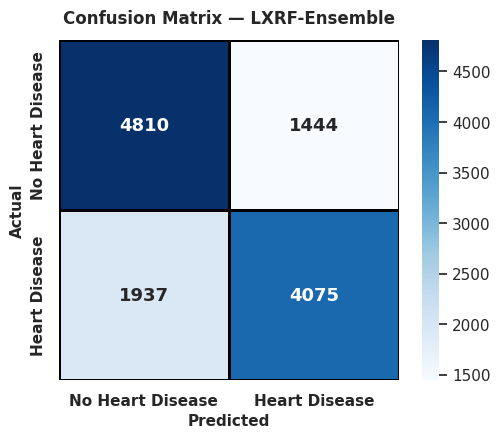

✅ Confusion matrix saved successfully.


In [ ]:
best_model = trained_models["LXRF-Ensemble (Proposed)"]
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5.5, 4.5), facecolor="white")
ax = plt.gca()

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="black",
    square=True,
    cbar=True,
    annot_kws={"size": 13, "weight": "bold"},
    xticklabels=["No Heart Disease", "Heart Disease"],
    yticklabels=["No Heart Disease", "Heart Disease"]
)

ax.set_title("Confusion Matrix — LXRF-Ensemble", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Predicted", fontsize=11, fontweight="bold")
ax.set_ylabel("Actual", fontsize=11, fontweight="bold")

plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

plt.tight_layout()
plt.savefig("LXRF_Confusion_Matrix.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("✅ Confusion matrix saved successfully.")


In [ ]:
df_fe = df.copy()

df_fe["pulse_pressure"] = df_fe["ap_hi"] - df_fe["ap_lo"]

df_fe["MAP"] = df_fe["ap_lo"] + (df_fe["pulse_pressure"] / 3)

df_fe["age_bmi"] = df_fe["age_years"] * df_fe["BMI"]

df_fe["chol_gluc_risk"] = df_fe["cholesterol"] + df_fe["gluc"]

df_fe["lifestyle_risk"] = df_fe["smoke"] + df_fe["alco"] - df_fe["active"]

df_fe["bp_age"] = df_fe["ap_hi"] * df_fe["age_years"]

df_fe["bmi_category"] = pd.cut(
    df_fe["BMI"],
    bins=[0, 18.5, 25, 30, 100],
    labels=[0, 1, 2, 3]
).astype(int)

print("New Features Added :", ["pulse_pressure", "MAP", "age_bmi", "chol_gluc_risk", "lifestyle_risk", "bp_age", "bmi_category"])
print("Dataset Shape :", df_fe.shape)
df_fe.head()


New Features Added : ['pulse_pressure', 'MAP', 'age_bmi', 'chol_gluc_risk', 'lifestyle_risk', 'bp_age', 'bmi_category']
Dataset Shape : (61329, 25)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,BMI,bp_category,Cardio_Status,bmi,pulse_pressure,MAP,age_bmi,chol_gluc_risk,lifestyle_risk,bp_age,bmi_category
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,Stage-1,No Heart Disease,21.967120,30,90.000000,1098.356009,2,-1,5500,1
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,Stage-2,Heart Disease,34.927679,50,106.666667,1921.022354,4,-1,7700,3
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,Stage-1,Heart Disease,23.507805,60,90.000000,1198.898072,4,0,6630,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,Stage-2,Heart Disease,28.710479,50,116.666667,1378.103008,2,-1,7200,2
5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0,60,29.384676,Stage-1,No Heart Disease,29.384676,40,93.333333,1763.080567,4,0,7200,2


In [ ]:
X_fe = df_fe.drop(columns=["id", "cardio", "bp_category", "Cardio_Status"])
y_fe = df_fe["cardio"]

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_fe
)

scaler_fe = StandardScaler()
X_train_fe_scaled = scaler_fe.fit_transform(X_train_fe)
X_test_fe_scaled = scaler_fe.transform(X_test_fe)

print("Train Shape :", X_train_fe.shape)
print("Test Shape  :", X_test_fe.shape)


Train Shape : (49063, 21)
Test Shape  : (12266, 21)


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

tuned_models = {}

lgbm_param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [4, 6, 8, -1],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0]
}

lgbm_search = RandomizedSearchCV(
    LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    param_distributions=lgbm_param_grid,
    n_iter=15,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lgbm_search.fit(X_train_fe, y_train_fe)
tuned_models["lightgbm"] = lgbm_search.best_estimator_
print("Best LightGBM Params :", lgbm_search.best_params_)
print("Best LightGBM CV F1  :", round(lgbm_search.best_score_, 4))


Best LightGBM Params : {'subsample': 0.85, 'num_leaves': 15, 'n_estimators': 600, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best LightGBM CV F1  : 0.7126


In [ ]:
xgb_param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "min_child_weight": [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", use_label_encoder=False),
    param_distributions=xgb_param_grid,
    n_iter=15,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_search.fit(X_train_fe, y_train_fe)
tuned_models["xgboost"] = xgb_search.best_estimator_
print("Best XGBoost Params :", xgb_search.best_params_)
print("Best XGBoost CV F1  :", round(xgb_search.best_score_, 4))


Best XGBoost Params : {'subsample': 1.0, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 1.0}
Best XGBoost CV F1  : 0.7128


In [ ]:
rf_param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [6, 10, 14, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=rf_param_grid,
    n_iter=15,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_search.fit(X_train_fe, y_train_fe)
tuned_models["random_forest"] = rf_search.best_estimator_
print("Best RF Params :", rf_search.best_params_)
print("Best RF CV F1  :", round(rf_search.best_score_, 4))


Best RF Params : {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}
Best RF CV F1  : 0.7109


In [ ]:
cat_param_grid = {
    "iterations": [300, 500, 800],
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7]
}

cat_search = RandomizedSearchCV(
    CatBoostClassifier(verbose=0, random_state=RANDOM_STATE),
    param_distributions=cat_param_grid,
    n_iter=10,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
cat_search.fit(X_train_fe, y_train_fe)
tuned_models["catboost"] = cat_search.best_estimator_
print("Best CatBoost Params :", cat_search.best_params_)
print("Best CatBoost CV F1  :", round(cat_search.best_score_, 4))


Best CatBoost Params : {'learning_rate': 0.05, 'l2_leaf_reg': 1, 'iterations': 500, 'depth': 4}
Best CatBoost CV F1  : 0.7123


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

lxrf_stacking = StackingClassifier(
    estimators=[
        ("lightgbm", tuned_models["lightgbm"]),
        ("xgboost", tuned_models["xgboost"]),
        ("random_forest", tuned_models["random_forest"])
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=5,
    n_jobs=-1
)

lxrf_stacking.fit(X_train_fe, y_train_fe)
y_pred_stack = lxrf_stacking.predict(X_test_fe)

acc = accuracy_score(y_test_fe, y_pred_stack)
prec = precision_score(y_test_fe, y_pred_stack)
rec = recall_score(y_test_fe, y_pred_stack)
f1 = f1_score(y_test_fe, y_pred_stack)

print("="*60)
print("LXRF-Ensemble (Tuned + Stacking + Feature Engineered)")
print("="*60)
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")


LXRF-Ensemble (Tuned + Stacking + Feature Engineered)
Accuracy  : 0.7281
Precision : 0.7424
Recall    : 0.6818
F1-Score  : 0.7108


In [ ]:
tuned_cat_model = tuned_models["catboost"]
y_pred_cat = tuned_cat_model.predict(X_test_fe)

acc_cat = accuracy_score(y_test_fe, y_pred_cat)
prec_cat = precision_score(y_test_fe, y_pred_cat)
rec_cat = recall_score(y_test_fe, y_pred_cat)
f1_cat = f1_score(y_test_fe, y_pred_cat)

print("="*60)
print("CatBoost (Tuned + Feature Engineered)")
print("="*60)
print(f"Accuracy  : {acc_cat:.4f}")
print(f"Precision : {prec_cat:.4f}")
print(f"Recall    : {rec_cat:.4f}")
print(f"F1-Score  : {f1_cat:.4f}")

final_results = pd.DataFrame([
    {"Model": "CatBoost (Tuned)", "Accuracy": acc_cat, "Precision": prec_cat, "Recall": rec_cat, "F1-Score": f1_cat},
    {"Model": "LXRF-Ensemble (Tuned Stacking)", "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}
])

comparison_df = pd.concat([results_df, final_results], ignore_index=True).sort_values(
    by="F1-Score", ascending=False
).reset_index(drop=True)

comparison_df


In [ ]:
import matplotlib.pyplot as plt


models = [
    'AdaBoost', 'RF', 'KNN', 'GB',
    'LightGBM', 'CatBoost', 'GNB',
    'LC-Boost', 'LXRF'
]

accuracy = [
    0.7199,
    0.7024,
    0.7121,
    0.7273,
    0.7275,
    0.7265,
    0.7088,
    0.7582,
    0.7881
]

colors = [
    "#3498db",
    "#3498db",
    "#3498db",
    "#3498db",
    "#3498db",
    "#3498db",
    "#3498db",
    "#f39c12",
    "#e74c3c"
]


fig, ax = plt.subplots(figsize=(10, 5), facecolor="white")
ax.set_facecolor("white")

bars = ax.bar(
    models,
    accuracy,
    color=colors,
    edgecolor="black",
    linewidth=2.2,
    width=0.85
)


for bar in bars:
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.0025,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="black"
    )


ax.set_title(
    "Accuracy Comparison of Machine Learning Models",
    fontsize=15,
    fontweight="bold",
    pad=12
)


ax.set_xlabel(
    "Machine Learning Models",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Accuracy",
    fontsize=13,
    fontweight="bold"
)


ax.tick_params(
    axis='both',
    labelsize=11,
    width=2,
    length=6,
    colors="black"
)

for tick in ax.get_xticklabels():
    tick.set_fontweight("bold")

for tick in ax.get_yticklabels():
    tick.set_fontweight("bold")


ax.set_ylim(0.65, 0.83)


ax.grid(
    axis='y',
    linestyle='--',
    linewidth=0.8,
    alpha=0.4
)

for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color("black")


plt.tight_layout()

plt.savefig(
    "Accuracy_Comparison.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("✅ Accuracy comparison figure saved successfully.")